# IFB 08 — Historical Replay Validation

Compare the new operational feature builder against the exact historical feature logic used by the original Random Forest and XGBoost branches.

In [1]:
# Import libraries
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Define config paths
PROJECT_ROOT = Path.cwd()
while (
    not (PROJECT_ROOT / "src").exists()
    and PROJECT_ROOT != PROJECT_ROOT.parent
):
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CONFIG_PATH = (
    PROJECT_ROOT
    / "configs"
    / "inference_feature_builder.yaml"
)

print("Project root:", PROJECT_ROOT)
print("IFB config:", CONFIG_PATH)

Project root: e:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Capstone\DataLocal\ontario-electricity-peak-risk
IFB config: e:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Capstone\DataLocal\ontario-electricity-peak-risk\configs\inference_feature_builder.yaml


In [3]:
# Import module for running inference_feature_builder
from src.ontario_peak_risk.modeling.common import (
    load_modeling_config,
    load_feature_dataset,
)
from src.ontario_peak_risk.inference_feature_builder.io import (
    load_ifb_config,
    resolve_path,
)
from src.ontario_peak_risk.inference_feature_builder.replay import (
    historical_replay_comparison,
)
from src.ontario_peak_risk.inference_feature_builder.plotting import (
    replay_match_rate_plot,
)

In [4]:
config, project_root = load_ifb_config(CONFIG_PATH)

modeling_config, _ = load_modeling_config(
    resolve_path(
        project_root,
        config["paths"]["modeling_foundation_config"],
    )
)
feature_dataset = load_feature_dataset(modeling_config, project_root)

# Historical replay must remain inside the original historical dataset.
REPLAY_ORIGIN = pd.Timestamp("2025-12-30 23:00:00")
FSAS = list(config["inference"]["fsas"])

print("Feature dataset maximum:", feature_dataset["timestamp"].max())
print("Replay origin:", REPLAY_ORIGIN)

Feature dataset maximum: 2025-12-31 23:00:00
Replay origin: 2025-12-30 23:00:00


In [5]:
summary, detail = historical_replay_comparison(
    feature_dataset=feature_dataset,
    forecast_origin=REPLAY_ORIGIN,
    fsas=FSAS,
    artifacts_dir=resolve_path(
        project_root,
        config["paths"]["artifacts_dir"],
    ),
    config=config,
)

display(summary)

if not detail.empty:
    print("Mismatch examples:")
    display(detail.head(50))

all_pass = summary["status"].eq("PASS").all()
print("All feature checks PASS:", all_pass)

if not all_pass:
    failed = summary.loc[summary["status"].eq("FAIL")]
    display(failed)
    raise ValueError(
        "Historical replay failed. Do not proceed to IFB_09 until resolved."
    )

,model,horizon,feature,rows_compared,matching_rows,match_rate_pct,max_abs_difference,status
0,rf,1,target_hour,6,6,100.0,0,PASS
1,rf,1,target_weekday,6,6,100.0,0,PASS
2,rf,1,target_month,6,6,100.0,0,PASS
3,rf,1,target_is_weekend,6,6,100.0,0,PASS
4,rf,1,target_hour_sin,6,6,100.0,0.0,PASS
...,...,...,...,...,...,...,...,...
1051,xgb,24,origin__Rel Hum (%),6,6,100.0,0.0,PASS
1052,xgb,24,origin__Stn Press (kPa),6,6,100.0,0.0,PASS
1053,xgb,24,origin__reported_premise_count,6,6,100.0,0,PASS
1054,xgb,24,fsa,6,6,100.0,<NA>,PASS


All feature checks PASS: True


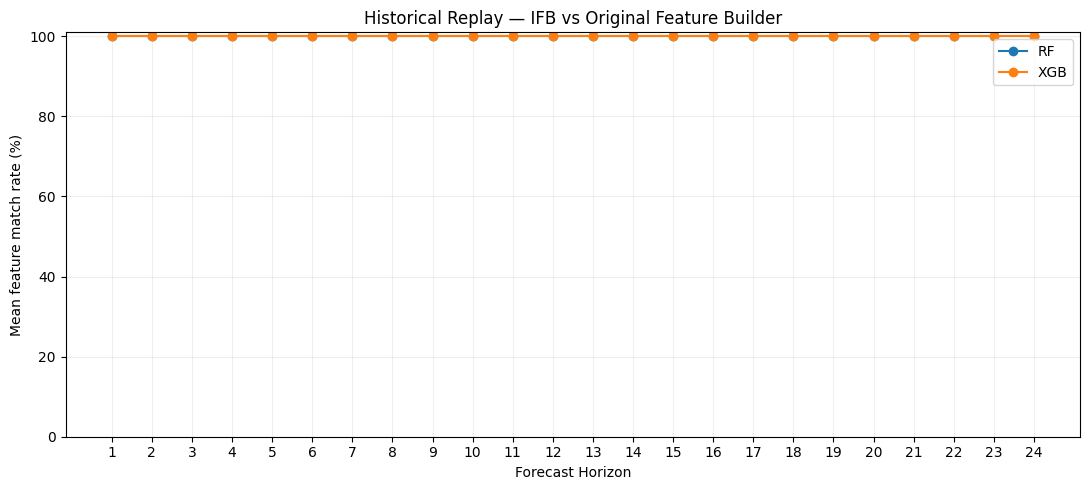

IFB_08 RESULT: PASS
The operational IFB reproduces the original historical feature logic.


In [6]:
replay_match_rate_plot(summary)
plt.show()

print("IFB_08 RESULT: PASS")
print("The operational IFB reproduces the original historical feature logic.")


Do not proceed to true operational inference if any replay feature fails. This
test is intended to prove that the operational builder reproduces the frozen
development-time model inputs.
